## Segmentación con Watershed

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

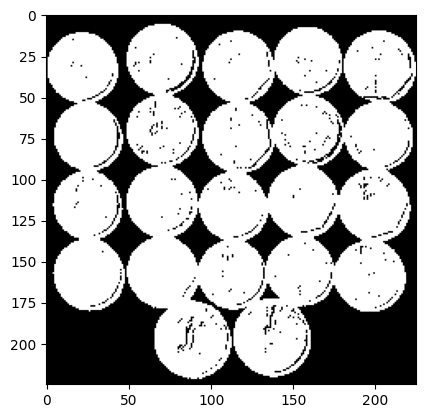

In [2]:
imagen = cv2.imread("img/coins.jpeg")
imagen_gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
_, imagen_bin = cv2.threshold(imagen_gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

plt.imshow(imagen_bin, cmap="gray")
plt.show()

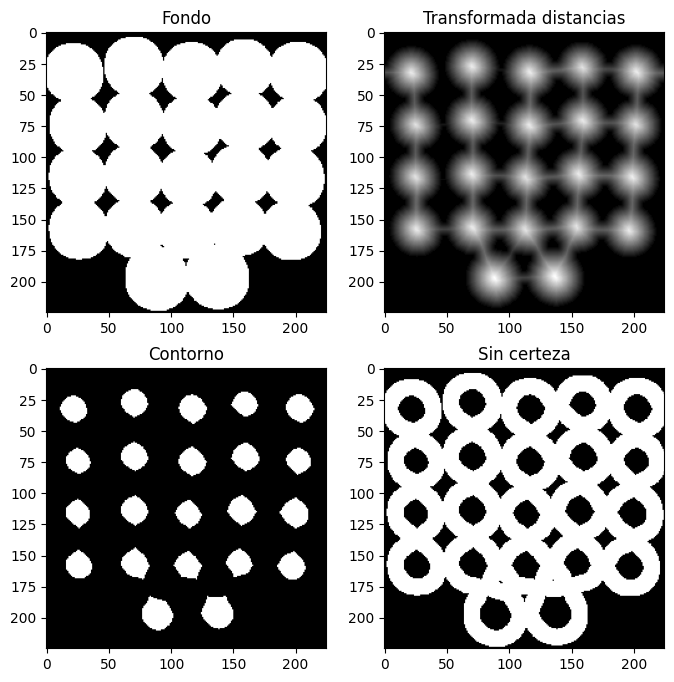

In [3]:
# Operaciones morfológicas - Ruido y Separación
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
kernel = np.ones((3,3), np.uint8)

imagen_bin_morf = cv2.morphologyEx(imagen_bin, cv2.MORPH_CLOSE, kernel, iterations=1)
imagen_bin_fondo = cv2.dilate(imagen_bin_morf,kernel,iterations=2)
dist = cv2.distanceTransform(imagen_bin_morf, cv2.DIST_L2, 5)
_, imagen_bin_contorno = cv2.threshold(dist, 0.5 * dist.max(), 255, cv2.THRESH_BINARY)
imagen_bin_contorno = imagen_bin_contorno.astype(np.uint8)  
unknown = cv2.subtract(imagen_bin_fondo, imagen_bin_contorno)

axes[0,0].imshow(imagen_bin_fondo, cmap="gray")
axes[0,0].set_title("Fondo")
axes[0,1].imshow(dist, cmap="gray")
axes[0,1].set_title("Transformada distancias")
axes[1,0].imshow(imagen_bin_contorno, cmap="gray")
axes[1,0].set_title("Contorno")
axes[1,1].imshow(unknown, cmap="gray")
axes[1,1].set_title("Sin certeza")
plt.show()

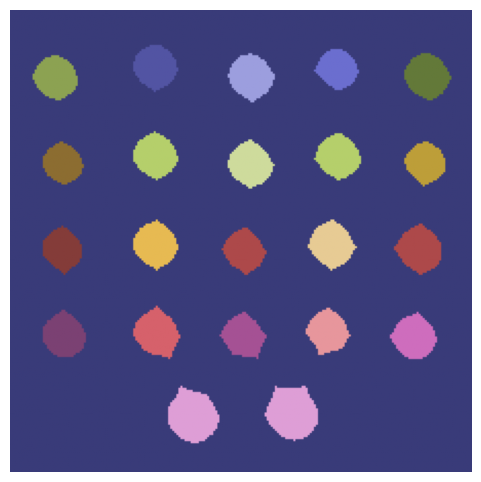

In [5]:
ret, marcadores = cv2.connectedComponents(imagen_bin_contorno)


marcadores += 1
marcadores[unknown == 255] = 0

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(marcadores, cmap="tab20b")
ax.axis('off')
plt.show()

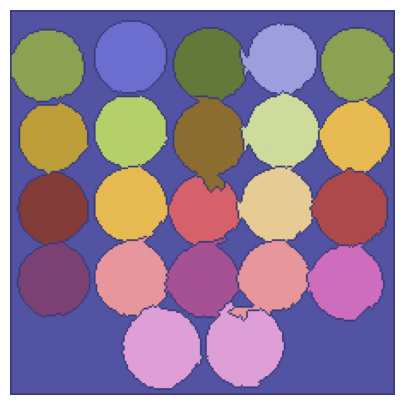

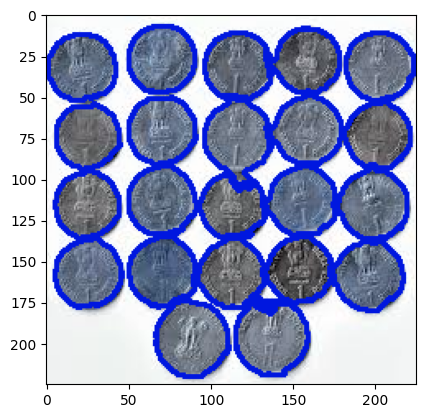

In [6]:
# Watershed Algorithm
marcadores_watershed = cv2.watershed(imagen, marcadores)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(marcadores_watershed, cmap="tab20b")
ax.axis('off')
plt.show()


etiquetas = np.unique(marcadores_watershed)
monedas = []
for etiqueta in etiquetas[2:]:
    target = np.where(marcadores_watershed == etiqueta, 255, 0).astype(np.uint8)
    contours, hierarchy = cv2.findContours(
        target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    monedas.append(contours[0])

img = cv2.drawContours(imagen, monedas, -1, color=(0, 23, 223), thickness=2)
plt.imshow(img)